In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import unicodedata
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import itertools
import seaborn as sns
from scipy.stats import chi2_contingency, ttest_ind, mannwhitneyu
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report


In [ ]:
import os
cwd = os.getcwd()  # Get the current working directory (cwd)
files = os.listdir(cwd)  # 
print("Files in %r: %s" % (cwd, files))

In [ ]:
df = pd.read_excel("נתונים למחקר של מאריא מעודכן ל 05.05.2025.xlsx")
df["Treatment_Date"] = pd.to_datetime(df["Treatment_Date"], dayfirst=True)
df["Failure_Treatment_Date"] = pd.to_datetime(df["Failure_Treatment_Date"], dayfirst=True)


In [ ]:
df
treatment_date = df.groupby(["Patient_ID", "Tooth_Num"])["Treatment_Date"].max().reset_index()
failed_treatment_date = df.groupby(["Patient_ID", "Tooth_Num"])["Failure_Treatment_Date"].min().reset_index()


קריאת הנתונים

פונקציה שעושה מבחני חי בריבוע

In [ ]:
import pandas as pd
import scipy.stats as stats

def check_categorical_impact(data, dependent_var, independent_var):
    """
    בודקת האם המשתנה הבלתי תלוי משפיע על הצלחת השתל (משתנים קטגוריים בלבד).
    
    פרמטרים:
    - data: DataFrame
    - dependent_var: המשתנה התלוי (קטגוריאלי בינארי, למשל "הצלחה"/"כישלון")
    - independent_var: המשתנה הבלתי תלוי (קטגוריאלי)
    
    מחזירה:
    - תוצאת המבחן הסטטיסטי
    """
    # יצירת טבלת שכיחות
    contingency_table = pd.crosstab(data[dependent_var], data[independent_var])
    # בדיקה אם יש תאים עם פחות מ-5 תצפיות
    if (contingency_table < 5).any().any():
        # שימוש במבחן פישר אם יש תאים עם פחות מ-5 תצפיות
        if contingency_table.shape == (2, 2):  # מבחן פישר מתאים רק לטבלת 2x2
            stat, p_value = stats.fisher_exact(contingency_table.to_numpy())
            test_name = "מבחן פישר"
        else:
            raise ValueError("מבחן פישר נתמך רק עבור טבלת 2x2. נסה קבוצות עם יותר תצפיות.")
    else:
        # שימוש במבחן חי-בריבוע (\(\chi^2\))
        stat, p_value, _, _ = stats.chi2_contingency(contingency_table)
        test_name = "מבחן חי-בריבוע (χ²)"
    
    # החזרת התוצאות
    return {
        "מבחן סטטיסטי": test_name,
        "טבלה": contingency_table,
        "סטטיסטי": stat,
        "ערך-p": p_value,
        "תוצאה": "מובהק" if p_value < 0.05 else "לא מובהק"
    }


יצירת טבלה חדשה המסכמת את הנתונים בשורה אחת לכל מטופל ושן, עם הטבלה הזאת נעבוד בהמשך

In [ ]:
# שלב 1: בדיקה אם הופיע "איטום כותרתי" לכל ID ושן
df["Has_Sealing"] = df["סיווג"].str.contains("איטום כותרתי", na=False)

# שלב 2: בדיקה אם הופיע "הכתרה (עבר כתר)" לכל ID ושן
df["Has_Crown"] = df["סיווג"].str.contains("הכתרה", na=False)

# שלב 3: מציאת תאריך הכי מאוחר של "קודי פתיחה" לכל ID ושן
opening_codes = df[df["סיווג"].str.contains("קודי פתיחה-", na=False)]
latest_opening_date = opening_codes.groupby(["Patient_ID", "Tooth_Num"])["Treatment_Date"].max().reset_index()
latest_opening_date.rename(columns={"Treatment_Date": "Latest_Opening_Date"}, inplace=True)

latest_opening = opening_codes.groupby(["Patient_ID", "Tooth_Num"])["סיווג"].max().reset_index()

# שלב 4: מציאת תאריך "איטום כותרתי" לכל ID ושן
sealing_dates = df[df["סיווג"].str.contains("איטום כותרתי", na=False)]
sealing_dates = sealing_dates.groupby(["Patient_ID", "Tooth_Num"])["Treatment_Date"].min().reset_index()
sealing_dates.rename(columns={"Treatment_Date": "Sealing_Date"}, inplace=True)

# שלב 5: מציאת תאריך "הכתרה" לכל ID ושן
crown_dates = df[df["סיווג"].str.contains("הכתרה", na=False)]
crown_dates = crown_dates.groupby(["Patient_ID", "Tooth_Num"])["Treatment_Date"].min().reset_index()
crown_dates.rename(columns={"Treatment_Date": "Crown_Date"}, inplace=True)

# שלב 6: שמירת ערך Treatment_Status לכל ID ושן
treatment_status = df.groupby(["Patient_ID", "Tooth_Num"])["Treatment_Status"].first().reset_index()

# שלב 7: שמירת ערכים של העמודות הרפואיות
medical_columns = ["Biphos", "Diabet", "Cancer_No", "Cancer_Yes", "Diabet_No", "Diabet_Yes",
                   "Hipertonia_No", "Hipertonia_Yes", "Osteoporosis_No", "Osteoporosis_Yes",
                   "Smok_No", "Smok_Yes"]

medical_data = df.groupby(["Patient_ID", "Tooth_Num"])[medical_columns].first().reset_index()

failure_dates = df.groupby(["Patient_ID", "Tooth_Num"])["Failure_Treatment_Date"].min().reset_index()

# שילוב הנתונים
final_df = df.groupby(["Patient_ID", "Tooth_Num"]).agg(
    Has_Sealing=("Has_Sealing", "max"),
    Has_Crown=("Has_Crown", "max")
).reset_index()


final_df = final_df.merge(latest_opening_date, on=["Patient_ID", "Tooth_Num"], how="left")
final_df = final_df.merge(latest_opening, on=["Patient_ID", "Tooth_Num"], how="left")
final_df = final_df.merge(sealing_dates, on=["Patient_ID", "Tooth_Num"], how="left")
final_df = final_df.merge(crown_dates, on=["Patient_ID", "Tooth_Num"], how="left")
final_df = final_df.merge(treatment_status, on=["Patient_ID", "Tooth_Num"], how="left")
final_df = final_df.merge(medical_data, on=["Patient_ID", "Tooth_Num"], how="left")

final_df = final_df.merge(failure_dates, on=["Patient_ID", "Tooth_Num"], how="left")


# חישוב הפרשי הזמן
final_df["Time_Diff_Sealing"] = (final_df["Sealing_Date"] - final_df["Latest_Opening_Date"]).dt.days
final_df["Time_Diff_Crown"] = (final_df["Crown_Date"] - final_df["Latest_Opening_Date"]).dt.days
final_df["Time_To_Failure"] = (failed_treatment_date['Failure_Treatment_Date'] - treatment_date['Treatment_Date']).dt.days.dropna()


final_df = final_df.rename(columns={'סיווג': 'open_code'})

In [ ]:
final_df["Time_Diff_Crown_or_Sealing"] = np.where(
    final_df["Time_Diff_Sealing"].notna() & final_df["Time_Diff_Crown"].notna(),  # אם יש מספר בשתי העמודות
    final_df[["Time_Diff_Sealing", "Time_Diff_Crown"]].min(axis=1),        # קח את המינימום
    final_df["Time_Diff_Sealing"].fillna(final_df["Time_Diff_Crown"])             # אחרת, קח את הערך הקיים או השאר NaN
)

final_df["has_Crown_or_Sealing"] = final_df["Has_Sealing"] | final_df["Has_Crown"]

הפיכת המשתנים לבינאריים כדי שיתאימו לרגרסיה

In [ ]:
final_df['Jaw'] = np.where(
    final_df['Tooth_Num'].between(0, 29),  # תנאי: האם בטווח 0–29
    'Upper Jaw',  # אם כן - לסת עליונה
    'Lower Jaw'   # אחרת - לסת תחתונה
)
final_df['Jaw_reg'] = final_df['Jaw'].apply(lambda x: 1 if x == 'Upper Jaw' else 0)

final_df['Biphos'] = np.where(final_df['Biphos'] == 'Y', 'Yes', 'No')
final_df['Biphos_reg'] = final_df['Biphos'].apply(lambda x: 1 if x == 'Yes' else 0)

final_df['Cancer_No'] = np.where(final_df['Cancer_No'] == 'Y', 'Yes', 'No')
final_df['Cancer_reg'] = final_df['Cancer_No'].apply(lambda x: 1 if x == 'Yes' else 0)

final_df['Diabet_No'] = np.where(final_df['Diabet_No'] == 'Y', 'Yes', 'No')
final_df['Diabet_reg'] = final_df['Diabet_No'].apply(lambda x: 1 if x == 'Yes' else 0)

final_df['Hipertonia_No'] = np.where(final_df['Hipertonia_No'] == 'Y', 'Yes', 'No')
final_df['Hipertonia_reg'] = final_df['Hipertonia_No'].apply(lambda x: 1 if x == 'Yes' else 0)

final_df['Smok_No'] = np.where(final_df['Smok_No'] == 'Y', 'Yes', 'No')
final_df['Smoking'] = final_df['Smok_No'].apply(lambda x: 1 if x == 'Yes' else 0)

final_df['Osteoporosis_No'] = np.where(final_df['Osteoporosis_No'] == 'Y', 'Yes', 'No')
final_df['Osteoporosis_reg'] = final_df['Osteoporosis_No'].apply(lambda x: 1 if x == 'Yes' else 0)

final_df['Treatment_Status_reg'] = final_df['Treatment_Status'].apply(lambda x: 1 if x == 'Success' else 0)

final_df['Has_Sealing_reg'] = final_df['Has_Sealing'].apply(lambda x: 1 if x  else 0)
final_df['Has_Crown_reg'] = final_df['Has_Crown'].apply(lambda x: 1 if x  else 0)

In [ ]:
final_df['Tooth_Num_num'] = pd.to_numeric(final_df['Tooth_Num'], errors='coerce')

def is_top_jaw(tooth):
    return (11 <= tooth <= 18) or (21 <= tooth <= 28)

def is_bottom_jaw(tooth):
    return (31 <= tooth <= 38) or (41 <= tooth <= 48)

final_df['is_top_jaw'] = final_df['Tooth_Num_num'].apply(lambda x: is_top_jaw(x) if pd.notnull(x) else False)
final_df['is_bottom_jaw'] = final_df['Tooth_Num_num'].apply(lambda x: is_bottom_jaw(x) if pd.notnull(x) else False)

# Add these two lines:
final_df['Jaw_reg_bool'] = final_df['Jaw_reg'].astype(bool)
final_df['top_jaw_match'] = final_df['is_top_jaw'] == final_df['Jaw_reg_bool']

top_jaw_df = final_df[final_df['is_top_jaw']]
bottom_jaw_df = final_df[final_df['is_bottom_jaw']]
neither_df = final_df[~(final_df['is_top_jaw'] | final_df['is_bottom_jaw'])]

print("Top jaw:", final_df['is_top_jaw'].sum())
print("Bottom jaw:", final_df['is_bottom_jaw'].sum())
print("Neither:", (~(final_df['is_top_jaw'] | final_df['is_bottom_jaw'])).sum())

mismatches = final_df[~final_df['top_jaw_match']]
print(mismatches[['Tooth_Num', 'is_bottom_jaw', 'Jaw_reg', 'Jaw_reg_bool']])

משתנה	OR	פרשנות
Biphos_reg (ביספוספונטים)	0.883	רווח הסמך מכיל 1, כלומר ההשפעה של ביספוספונטים אינה מובהקת סטטיסטית.
Cancer_reg (סרטן)	0.739	חולי סרטן בעלי סיכון נמוך ב-26.1% לכישלון השתל. רווח הסמך לא מכיל 1, כלומר ההשפעה מובהקת.
Diabet_reg (סוכרת)	0.791	חולי סוכרת בעלי סיכון נמוך ב-20.9% לכישלון השתל. רווח הסמך לא מכיל 1, כלומר ההשפעה מובהקת.
Hipertonia_reg (יתר לחץ דם)	0.603	יתר לחץ דם מפחית את הסיכון לכישלון ב-39.7%. רווח הסמך לא מכיל 1, כלומר ההשפעה מובהקת.
Smoking (עישון)	0.943	ההשפעה אינה מובהקת כי רווח הסמך מכיל 1.
Osteoporosis_reg (אוסטאופורוזיס)	0.657	אוסטאופורוזיס מפחית את הסיכון לכישלון ב-34.3%. רווח הסמך לא מכיל 1, כלומר ההשפעה מובהקת.
Jaw_reg (לסת)	1.244	גורם זה מעלה את הסיכון לכישלון ב-24.4%. רווח הסמך לא מכיל 1, כלומר ההשפעה מובהקת.
![image.png](attachment:image.png)

משתנה	OR	פרשנות
Biphos_reg (ביספוספונטים)	0.883	רווח הסמך מכיל 1, כלומר ההשפעה של ביספוספונטים אינה מובהקת סטטיסטית.
Cancer_reg (סרטן)	0.739	חולי סרטן בעלי סיכון נמוך ב-26.1% לכישלון השתל. רווח הסמך לא מכיל 1, כלומר ההשפעה מובהקת.
Diabet_reg (סוכרת)	0.791	חולי סוכרת בעלי סיכון נמוך ב-20.9% לכישלון השתל. רווח הסמך לא מכיל 1, כלומר ההשפעה מובהקת.
Hipertonia_reg (יתר לחץ דם)	0.603	יתר לחץ דם מפחית את הסיכון לכישלון ב-39.7%. רווח הסמך לא מכיל 1, כלומר ההשפעה מובהקת.
Smoking (עישון)	0.943	ההשפעה אינה מובהקת כי רווח הסמך מכיל 1.
Osteoporosis_reg (אוסטאופורוזיס)	0.657	אוסטאופורוזיס מפחית את הסיכון לכישלון ב-34.3%. רווח הסמך לא מכיל 1, כלומר ההשפעה מובהקת.
Jaw_reg (לסת)	1.244	גורם זה מעלה את הסיכון לכישלון ב-24.4%. רווח הסמך לא מכיל 1, כלומר ההשפעה מובהקת.
![image.png](attachment:image.png)

משתנה	OR	פרשנות
Biphos_reg (ביספוספונטים)	0.883	רווח הסמך מכיל 1, כלומר ההשפעה של ביספוספונטים אינה מובהקת סטטיסטית.
Cancer_reg (סרטן)	0.739	חולי סרטן בעלי סיכון נמוך ב-26.1% לכישלון השתל. רווח הסמך לא מכיל 1, כלומר ההשפעה מובהקת.
Diabet_reg (סוכרת)	0.791	חולי סוכרת בעלי סיכון נמוך ב-20.9% לכישלון השתל. רווח הסמך לא מכיל 1, כלומר ההשפעה מובהקת.
Hipertonia_reg (יתר לחץ דם)	0.603	יתר לחץ דם מפחית את הסיכון לכישלון ב-39.7%. רווח הסמך לא מכיל 1, כלומר ההשפעה מובהקת.
Smoking (עישון)	0.943	ההשפעה אינה מובהקת כי רווח הסמך מכיל 1.
Osteoporosis_reg (אוסטאופורוזיס)	0.657	אוסטאופורוזיס מפחית את הסיכון לכישלון ב-34.3%. רווח הסמך לא מכיל 1, כלומר ההשפעה מובהקת.
Jaw_reg (לסת)	1.244	גורם זה מעלה את הסיכון לכישלון ב-24.4%. רווח הסמך לא מכיל 1, כלומר ההשפעה מובהקת.
![image.png](attachment:image.png)

In [ ]:
final_df

In [ ]:
# success = final_df[final_df["Treatment_Status_reg"] == 1]
# failure = final_df[final_df["Treatment_Status_reg"] == 0]

# # השוואת משתנים מספריים בין הצלחה לכישלון
# for col in ["Time_Diff_Crown"]:  # הכניסי משתנים רציפים רלוונטיים
#     t_stat, p_ttest = ttest_ind(success[col], failure[col])
#     u_stat, p_mannwhitney = mannwhitneyu(success[col], failure[col])
#     print(f"{col}: t-test p={p_ttest:.4f}, Mann-Whitney p={p_mannwhitney:.4f}")


In [ ]:
final_df.columns

מבחני חי בריבוע

In [ ]:
categorical_cols = ["Biphos_reg", "Cancer_reg", "Diabet_reg", "Hipertonia_reg", "Smoking", "Osteoporosis_reg", "Jaw_reg", "Has_Sealing_reg", "Has_Crown_reg"]  # הכניסי משתנים קטגוריים רלוונטיים

results = {}

for col in categorical_cols:
    results[col] = check_categorical_impact(final_df, 'Treatment_Status', col)

results

# רגרסיות:

 ## רגרסיה כללית

In [ ]:
# בחירת משתנים מסבירים (explanatory variables)
features = ["Biphos_reg", "Cancer_reg", "Diabet_reg", "Hipertonia_reg", "Smoking", "Osteoporosis_reg", "Jaw_reg", "Has_Sealing_reg", "Has_Crown_reg"]  # הכניסי משתנים רלוונטיים
#["Biphos_reg", "Cancer_reg", "Diabet_reg", "Hipertonia_reg", "Smoking", "Osteoporosis_reg", "Jaw_reg", "Has_Sealing_reg", "Has_Crown_reg"] 
X = final_df[features]
y = final_df["Treatment_Status_reg"]

# הוספת קבוע למודל (intercept)
X = sm.add_constant(X)

# בניית המודל הלוגיסטי
model = sm.Logit(y, X)

# התאמת המודל
result = model.fit()

# סיכום התוצאות
print(result.summary())



odds ratios

In [ ]:
# חישוב Odds Ratio
odds_ratios = np.exp(result.params)

# חישוב רווח בר-סמך (95% CI)
conf = np.exp(result.conf_int())

# הכנסת התוצאות לטבלה מסודרת
odds_df = conf.copy()
odds_df.columns = ['2.5%', '97.5%']  # גבולות רווח בר-סמך
odds_df['Odds Ratio'] = odds_ratios

odds_df.round(3)

In [ ]:
import numpy as np
import pandas as pd

def summarize_logit_results(result, significance_level=0.05):
    """
    Summarizes a fitted statsmodels Logit (or similar) result.
    
    Parameters:
        result: Fitted statsmodels result object (e.g., from sm.Logit().fit())
        significance_level: Threshold for statistical significance (default 0.05)
        
    Returns:
        summary_df: DataFrame with Coef, OR, p-value, CI_lower, CI_upper, and Interpretation
    """
    summary_df = pd.DataFrame({
        'Coef': result.params,
        'OR': np.exp(result.params),
        'p-value': result.pvalues,
        'CI_lower': np.exp(result.conf_int()[0]),
        'CI_upper': np.exp(result.conf_int()[1])
    })

    def percent_change(row):
        if row['CI_lower'] <= 1 <= row['CI_upper'] or row['p-value'] > significance_level:
            return 'Not significant'
        elif row['OR'] > 1:
            return f"{(row['OR'] - 1) * 100:.1f}% more likely to succeed"
        elif row['OR'] < 1:
            return f"{(1 - row['OR']) * 100:.1f}% less likely to succeed"
        else:
            return "No change"

    summary_df['Interpretation'] = summary_df.apply(percent_change, axis=1)
    summary_df = summary_df[['Coef', 'OR', 'p-value', 'CI_lower', 'CI_upper', 'Interpretation']]
    return summary_df

summary_df = summarize_logit_results(result)
summary_df

משתנה	OR	פרשנות
Biphos_reg (ביספוספונטים)	1.056	רווח הסמך מכיל 1, כלומר ההשפעה של ביספוספונטים אינה מובהקת סטטיסטית.
Cancer_reg (סרטן)	0.821	הסיכוי לכישלון נמוך ב-17.9% בקרב חולי סרטן. רווח הסמך לא מכיל 1, כלומר ההשפעה מובהקת.
Diabet_reg (סוכרת)	0.859	הסיכון לכישלון נמוך ב-14.1% בקרב חולי סוכרת. רווח הסמך לא מכיל 1, כלומר ההשפעה מובהקת.
Hipertonia_reg (יתר לחץ דם)	0.741	הסיכון לכישלון נמוך ב-25.9% בקרב מטופלים עם יתר לחץ דם. רווח הסמך לא מכיל 1, כלומר ההשפעה מובהקת.
Smoking (עישון)	0.899	עישון מפחית את הסיכון לכישלון השתל ב-10.1%. רווח הסמך לא מכיל 1, כלומר ההשפעה מובהקת.
Osteoporosis_reg (אוסטאופורוזיס)	0.748	אוסטאופורוזיס מפחית את הסיכון לכישלון ב-25.2%. רווח הסמך לא מכיל 1, כלומר ההשפעה מובהקת.
Jaw_reg (לסת)	1.264	גורם זה מעלה את הסיכון לכישלון ב-26.4%. רווח הסמך לא מכיל 1, כלומר ההשפעה מובהקת.
Has_Sealing_reg (איטום כותרתי)	2.991	איטום כותרתי מעלה מאוד את הסיכון לכישלון פי 2.99. רווח הסמך לא מכיל 1, כלומר ההשפעה מובהקת מאוד.
Has_Crown_reg (כתר)	1.545	הימצאות כתר מעלה את הסיכון לכישלון ב-54.5%. רווח הסמך לא מכיל 1, כלומר ההשפעה מובהקת.
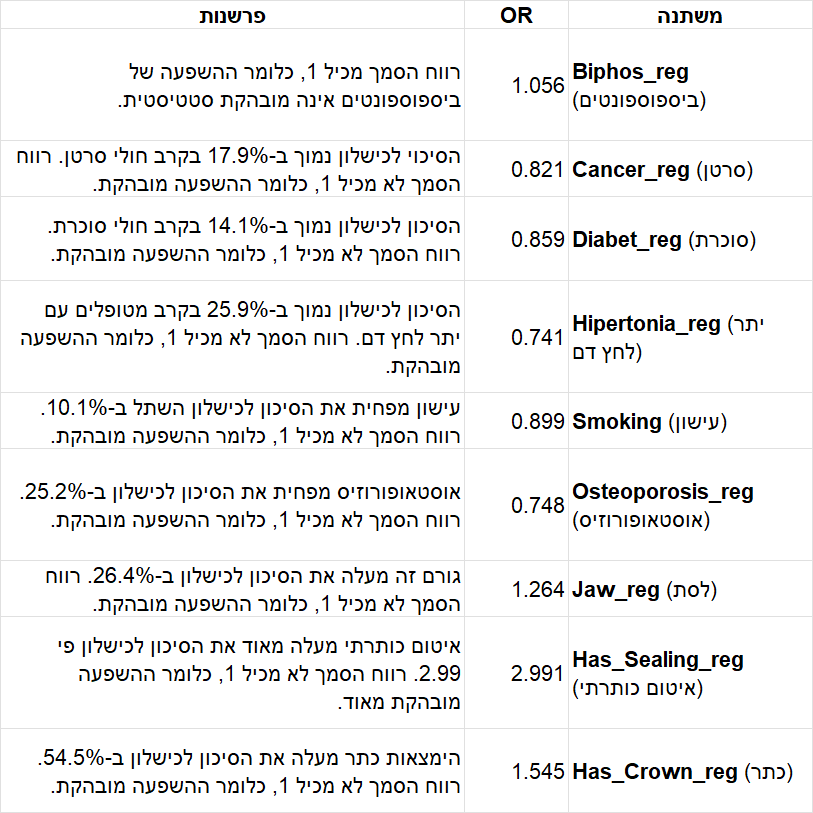

In [ ]:
final_df_renewal = final_df[final_df["open_code"] == 'קודי פתיחה- חידוש טיפול שורש']
final_df_Root_end_surgery = final_df[final_df["open_code"] == 'קודי פתיחה- טיפול שורש']
final_df_episectomy = final_df[final_df["open_code"] == 'קודי פתיחה- אפיסקטומי']

## רגרסיה רק למי שיש הכתרה או איטום כותרתי

In [ ]:
df_has_Crown_or_Sealing = final_df[final_df['has_Crown_or_Sealing']==True]
features = ["Biphos_reg", "Cancer_reg", "Diabet_reg", "Hipertonia_reg", "Smoking", "Osteoporosis_reg", "Jaw_reg"]#,"Time_Diff_Crown_or_Sealing"]  # הכניסי משתנים רלוונטיים
#["Biphos_reg", "Cancer_reg", "Diabet_reg", "Hipertonia_reg", "Smoking", "Osteoporosis_reg", "Jaw_reg", "Has_Sealing_reg", "Has_Crown_reg"] 
X = df_has_Crown_or_Sealing[features]
y = df_has_Crown_or_Sealing["Treatment_Status_reg"]

# Combine X and y to drop rows with any missing values
# data = pd.concat([X, y], axis=1).dropna() # we drop whoever has NaN in the Time diff for the crown or sealing because it means they didn't have it
# X = data[features]  # 'const' if you added it
# y = data["Treatment_Status_reg"]
# הוספת קבוע למודל (intercept)
X = sm.add_constant(X)

# בניית המודל הלוגיסטי
model = sm.Logit(y, X)

# התאמת המודל
result = model.fit()

# סיכום התוצאות
print(result.summary())


odds ratios

In [ ]:
# חישוב Odds Ratio
odds_ratios = np.exp(result.params)

# חישוב רווח בר-סמך (95% CI)
conf = np.exp(result.conf_int())

# הכנסת התוצאות לטבלה מסודרת
odds_df = conf.copy()
odds_df.columns = ['2.5%', '97.5%']  # גבולות רווח בר-סמך
odds_df['Odds Ratio'] = odds_ratios

odds_df.round(3)

In [ ]:
summary_df = summarize_logit_results(result)
summary_df

## רגרסיה לחידוש טיפול שורש

In [ ]:
features = ["Biphos_reg", "Cancer_reg", "Diabet_reg", "Hipertonia_reg", "Smoking", "Osteoporosis_reg", "Jaw_reg", "Has_Sealing_reg", "Has_Crown_reg"]  # הכניסי משתנים רלוונטיים

X = final_df_renewal[features]
y = final_df_renewal["Treatment_Status_reg"]

# הוספת קבוע למודל (intercept)
X = sm.add_constant(X)

# בניית המודל הלוגיסטי
model = sm.Logit(y, X)

# התאמת המודל
result = model.fit()

# סיכום התוצאות
print(result.summary())



odds ratios

In [ ]:
# חישוב Odds Ratio
odds_ratios = np.exp(result.params)

# חישוב רווח בר-סמך (95% CI)
conf = np.exp(result.conf_int())

# הכנסת התוצאות לטבלה מסודרת
odds_df = conf.copy()
odds_df.columns = ['2.5%', '97.5%']  # גבולות רווח בר-סמך
odds_df['Odds Ratio'] = odds_ratios

odds_df.round(3)

In [ ]:
summary_df = summarize_logit_results(result)
summary_df

משתנה	OR	פרשנות
Biphos_reg (ביספוספונטים)	1.232	התרופה עשויה להעלות את הסיכון לכישלון ב-23.2%, אך רווח הסמך רחב ומכיל 1, כלומר לא מובהק.
Cancer_reg (סרטן)	0.973	אין השפעה מובהקת של סרטן על כישלון השתל, כי רווח הסמך מכיל 1.
Diabet_reg (סוכרת)	0.966	חולי סוכרת אינם שונים משמעותית בסיכון לכישלון השתל, כי רווח הסמך מכיל 1.
Hipertonia_reg (יתר לחץ דם)	0.816	יתר לחץ דם מפחית את הסיכון לכישלון ב-18.4%. רווח הסמך לא מכיל 1, כלומר השפעה מובהקת.
Smoking (עישון)	1.007	אין השפעה מובהקת של עישון על כישלון השתל, כי רווח הסמך מכיל 1.
Osteoporosis_reg (אוסטאופורוזיס)	0.904	אין השפעה מובהקת של אוסטאופורוזיס על כישלון השתל, כי רווח הסמך מכיל 1.
Jaw_reg (לסת)	1.331	גורם זה מעלה את הסיכון לכישלון ב-33.1%. רווח הסמך לא מכיל 1, כלומר ההשפעה מובהקת.
Has_Sealing_reg (יש איטום)	2.094	איטום מעלה משמעותית את הסיכון לכישלון פי 2. רווח הסמך לא מכיל 1, ולכן ההשפעה מובהקת.
Has_Crown_reg (יש כתר)	1.465	כתר מעלה את הסיכון לכישלון ב-46.5%. רווח הסמך לא מכיל 1, כלומר ההשפעה מובהקת.
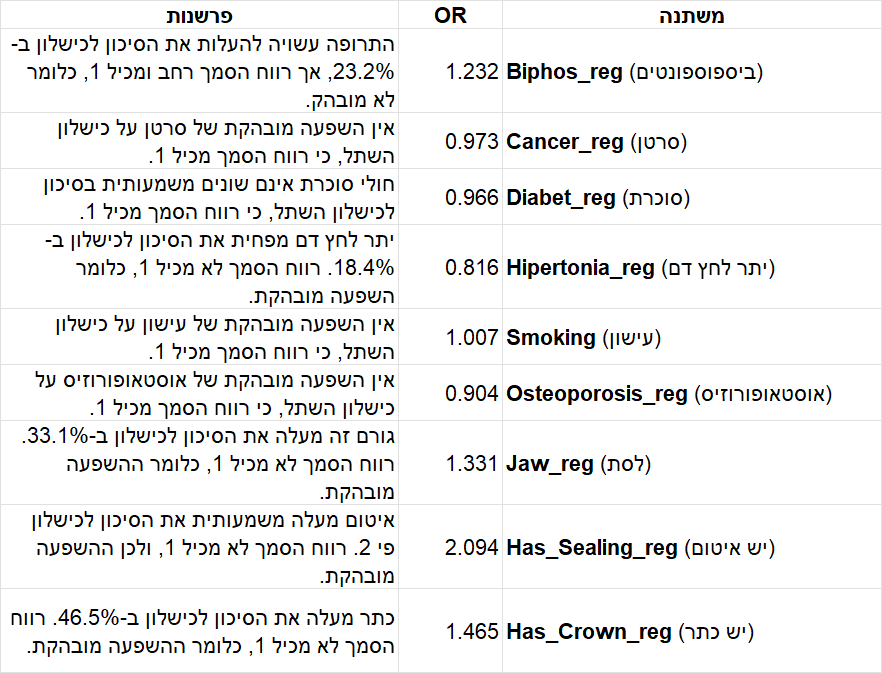

## רגרסיה לחידוש טיפול שורש ורק למי שיש הכתרה או איטום כותרתי 

In [ ]:
df_has_Crown_or_Sealing_renewal = df_has_Crown_or_Sealing[df_has_Crown_or_Sealing["open_code"] == 'קודי פתיחה- חידוש טיפול שורש']
features = ["Biphos_reg", "Cancer_reg", "Diabet_reg", "Hipertonia_reg", "Smoking", "Osteoporosis_reg", "Jaw_reg","Time_Diff_Crown_or_Sealing"]  # הכניסי משתנים רלוונטיים

X = df_has_Crown_or_Sealing_renewal[features]
y = df_has_Crown_or_Sealing_renewal["Treatment_Status_reg"]

# הוספת קבוע למודל (intercept)
X = sm.add_constant(X)

# בניית המודל הלוגיסטי
model = sm.Logit(y, X)

# התאמת המודל
result = model.fit()

# סיכום התוצאות
print(result.summary())



odds ratios

In [ ]:
# חישוב Odds Ratio
odds_ratios = np.exp(result.params)

# חישוב רווח בר-סמך (95% CI)
conf = np.exp(result.conf_int())

# הכנסת התוצאות לטבלה מסודרת
odds_df = conf.copy()
odds_df.columns = ['2.5%', '97.5%']  # גבולות רווח בר-סמך
odds_df['Odds Ratio'] = odds_ratios

odds_df.round(3)

In [ ]:
summary_df = summarize_logit_results(result)
summary_df

משתנה	OR	פרשנות
Biphos_reg (ביספוספונטים)	0.811	התרופה עשויה להפחית את הסיכון לכישלון ב-18.9%, אך רווח הסמך רחב ומכיל 1, כלומר לא מובהק.
Cancer_reg (סרטן)	0.84	אין השפעה מובהקת של סרטן על כישלון השתל, כי רווח הסמך מכיל 1.
Diabet_reg (סוכרת)	0.965	חולי סוכרת אינם שונים משמעותית בסיכון לכישלון השתל, כי רווח הסמך מכיל 1.
Hipertonia_reg (יתר לחץ דם)	0.707	יתר לחץ דם מפחית את הסיכון לכישלון ב-29.3%. רווח הסמך לא מכיל 1, כלומר ההשפעה מובהקת.
Smoking (עישון)	1.034	אין השפעה מובהקת של עישון על כישלון השתל, כי רווח הסמך מכיל 1.
Osteoporosis_reg (אוסטאופורוזיס)	0.966	אין השפעה מובהקת של אוסטאופורוזיס על כישלון השתל, כי רווח הסמך מכיל 1.
Jaw_reg (לסת)	1.231	גורם זה מעלה את הסיכון לכישלון ב-23.1%. רווח הסמך לא מכיל 1, כלומר ההשפעה מובהקת.
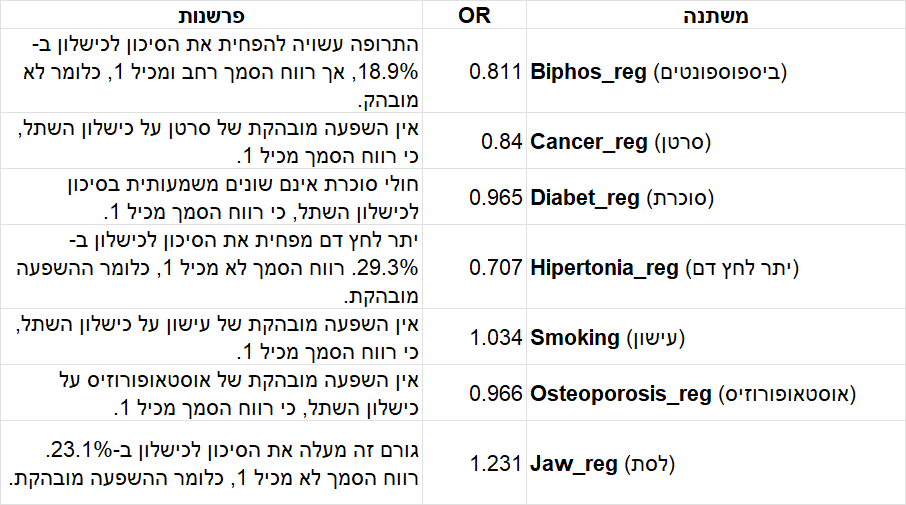

## רגרסיה לטיפול שורש

In [ ]:
features = ["Biphos_reg", "Cancer_reg", "Diabet_reg", "Hipertonia_reg", "Smoking", "Osteoporosis_reg", "Jaw_reg", "Has_Sealing_reg", "Has_Crown_reg"]  # הכניסי משתנים רלוונטיים

X = final_df_Root_end_surgery[features]
y =final_df_Root_end_surgery["Treatment_Status_reg"]

# הוספת קבוע למודל (intercept)
X = sm.add_constant(X)

# בניית המודל הלוגיסטי
model = sm.Logit(y, X)

# התאמת המודל
result = model.fit()

# סיכום התוצאות
print(result.summary())

odds ratios

In [ ]:
# חישוב Odds Ratio
odds_ratios = np.exp(result.params)

# חישוב רווח בר-סמך (95% CI)
conf = np.exp(result.conf_int())

# הכנסת התוצאות לטבלה מסודרת
odds_df = conf.copy()
odds_df.columns = ['2.5%', '97.5%']  # גבולות רווח בר-סמך
odds_df['Odds Ratio'] = odds_ratios

odds_df.round(3)

In [ ]:
summary_df = summarize_logit_results(result)
summary_df

משתנה	OR	פרשנות
Biphos_reg (ביספוספונטים)	1.016	התרופה עשויה להפחית או להגדיל את הסיכון לכישלון, אך רווח הסמך כולל את 1, כלומר לא מובהק.
Cancer_reg (סרטן)	0.782	אין השפעה מובהקת של סרטן על כישלון השתל, כי רווח הסמך מכיל את 1.
Diabet_reg (סוכרת)	0.815	חולי סוכרת אינם שונים באופן מובהק בסיכון לכישלון השתל, כי רווח הסמך מכיל את 1.
Hipertonia_reg (יתר לחץ דם)	0.715	יתר לחץ דם עשוי להפחית את הסיכון לכישלון השתל ב-28.5%, אך רווח הסמך מכיל את 1, כלומר לא מובהק.
Smoking (עישון)	0.862	אין השפעה מובהקת של עישון על כישלון השתל, כי רווח הסמך מכיל את 1.
Osteoporosis_reg (אוסטאופורוזיס)	0.711	אין השפעה מובהקת של אוסטאופורוזיס על כישלון השתל, כי רווח הסמך מכיל את 1.
Jaw_reg (לסת)	1.264	גורם זה מעלה את הסיכון לכישלון השתל ב-26.4%, ורווח הסמך לא מכיל את 1, כלומר ההשפעה מובהקת.
Has_Sealing_reg (איטום)	3.066	יש סיכון גבוה יותר לכישלון השתל כאשר יש איטום, עם סיכון גבוה פי 3.066. ההשפעה מובהקת.
Has_Crown_reg (כתר)	1.685	יש סיכון גבוה יותר לכישלון השתל כאשר יש כתר, עם סיכון גבוה פי 1.685. ההשפעה מובהקת.
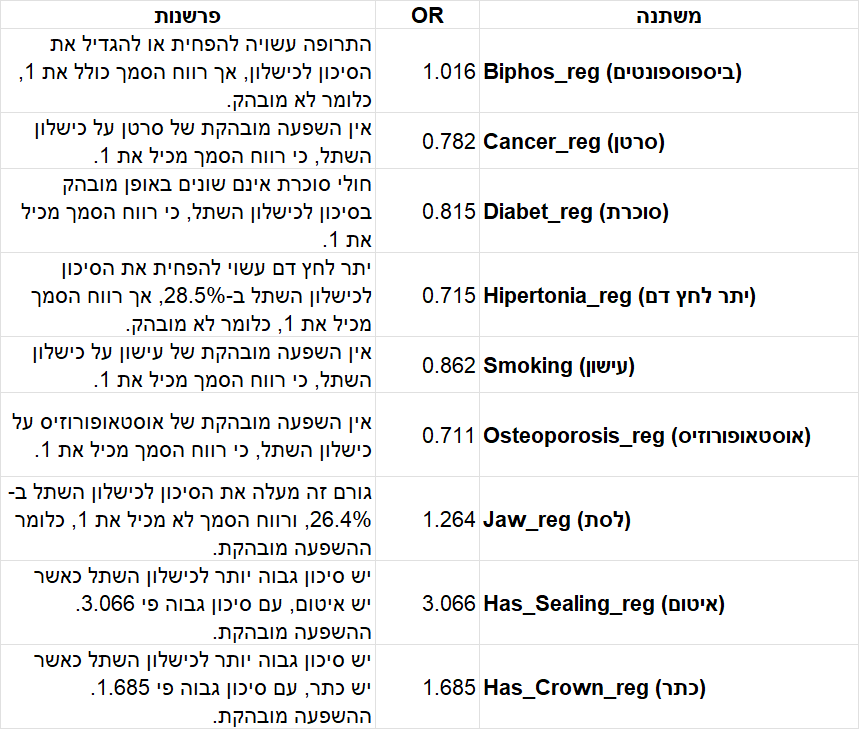

## רגרסיה לטיפול שורש ורק למי שיש הכתרה או איטום כותרתי 

In [ ]:
df_has_Crown_or_Sealing_Root_end_surgery = df_has_Crown_or_Sealing[df_has_Crown_or_Sealing["open_code"] == 'קודי פתיחה- טיפול שורש']
features = ["Biphos_reg", "Cancer_reg", "Diabet_reg", "Hipertonia_reg", "Smoking", "Osteoporosis_reg", "Jaw_reg","Time_Diff_Crown_or_Sealing"]  # הכניסי משתנים רלוונטיים

X = df_has_Crown_or_Sealing_Root_end_surgery[features].dropna()
y = df_has_Crown_or_Sealing_Root_end_surgery["Treatment_Status_reg"].dropna()

# הוספת קבוע למודל (intercept)
X = sm.add_constant(X)

# בניית המודל הלוגיסטי
model = sm.Logit(y, X)

# התאמת המודל
result = model.fit()

# סיכום התוצאות
print(result.summary())


odds ratios

In [ ]:
# חישוב Odds Ratio
odds_ratios = np.exp(result.params)

# חישוב רווח בר-סמך (95% CI)
conf = np.exp(result.conf_int())

# הכנסת התוצאות לטבלה מסודרת
odds_df = conf.copy()
odds_df.columns = ['2.5%', '97.5%']  # גבולות רווח בר-סמך
odds_df['Odds Ratio'] = odds_ratios

print(odds_df.round(3))

In [ ]:
summary_df = summarize_logit_results(result)
summary_df

משתנה	OR	פרשנות
Biphos_reg (ביספוספונטים)	0.9	התרופה עשויה להפחית או להגדיל את הסיכון לכישלון, אך רווח הסמך כולל את 1, כלומר לא מובהק.
Cancer_reg (סרטן)	0.71	אין השפעה מובהקת של סרטן על כישלון השתל, כי רווח הסמך מכיל את 1.
Diabet_reg (סוכרת)	0.732	חולי סוכרת אינם שונים באופן מובהק בסיכון לכישלון השתל, כי רווח הסמך מכיל את 1.
Hipertonia_reg (יתר לחץ דם)	0.571	יתר לחץ דם עשוי להפחית את הסיכון לכישלון השתל ב-42.9%, אך רווח הסמך מכיל את 1, כלומר לא מובהק.
Smoking (עישון)	0.904	אין השפעה מובהקת של עישון על כישלון השתל, כי רווח הסמך מכיל את 1.
Osteoporosis_reg (אוסטאופורוזיס)	0.593	אין השפעה מובהקת של אוסטאופורוזיס על כישלון השתל, כי רווח הסמך מכיל את 1.
Jaw_reg (לסת)	1.282	גורם זה מעלה את הסיכון לכישלון השתל ב-28.2%, ורווח הסמך לא מכיל את 1, כלומר ההשפעה מובהקת.
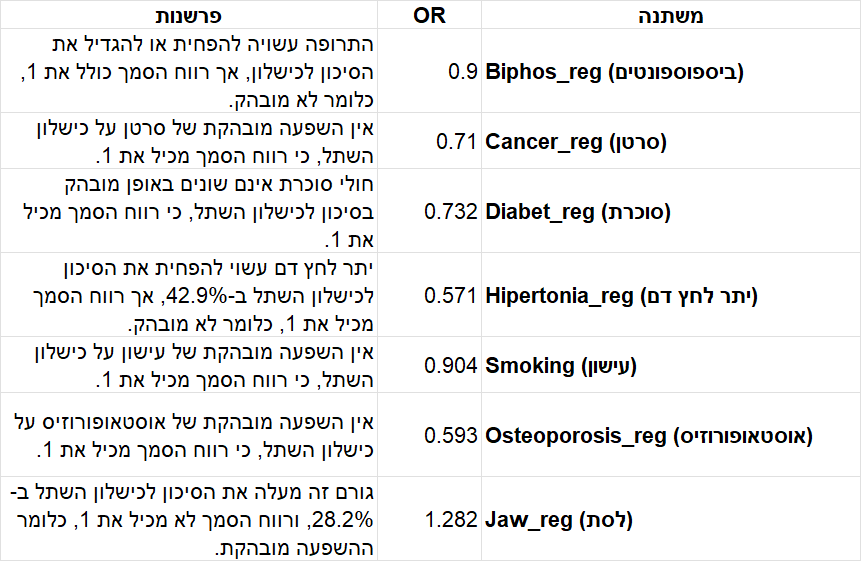

## רגרסיה לאפיסקטומי 

In [ ]:
# features = ["Biphos_reg", "Cancer_reg", "Diabet_reg", "Hipertonia_reg", "Smoking", "Osteoporosis_reg", "Jaw_reg", "Has_Sealing_reg", "Has_Crown_reg"]  # הכניסי משתנים רלוונטיים
features = [ "Diabet_reg", "Hipertonia_reg", "Smoking", "Jaw_reg", "Has_Sealing_reg", "Has_Crown_reg"]  # הכניסי משתנים רלוונטיים

X = final_df_episectomy[features]
y = final_df_episectomy["Treatment_Status_reg"]

for col in features:
    table = pd.crosstab(final_df_episectomy[col], final_df_episectomy["Treatment_Status_reg"])
    print(f"\nCrosstab for {col} vs Treatment_Status_reg:")
    print(table)
# הוספת קבוע למודל (intercept)
X = sm.add_constant(X)

# בניית המודל הלוגיסטי
model = sm.Logit(y, X)

# התאמת המודל
result = model.fit()

# סיכום התוצאות
print(result.summary())


לא ניתן להסיק לגבי הרגרסיה הזאת, מספר התצפיות הינו קטן ולכן לרא נוכל להשתמש בה

In [ ]:
import scipy.stats as stats

for col in features:
    table = pd.crosstab(final_df_episectomy[col], final_df_episectomy["Treatment_Status_reg"])
    if table.shape == (2, 2):
        oddsratio, p_value = stats.fisher_exact(table)
        print(f"\nFisher's Exact Test for {col}: Odds Ratio = {oddsratio:.2f}, p-value = {p_value:.4f}")
    else:
        print(f"\n{col} is not binary, skipping Fisher's Exact Test.")

for col in features:
    table = pd.crosstab(final_df_episectomy[col], final_df_episectomy["Treatment_Status_reg"])
    if table.shape[0] > 2 or table.shape[1] > 2:
        chi2, p, dof, expected = stats.chi2_contingency(table)
        print(f"\nChi-squared Test for {col}: chi2 = {chi2:.2f}, p-value = {p:.4f}")

קפלן מאייר

In [ ]:
import pandas as pd
import numpy as np
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

def plot_kaplan_meier(
    df,
    time_col='Time_To_Failure',
    event_col='Treatment_Status',
    event_label='Failure',
    followup_col=None
):
    """
    Plots Kaplan-Meier survival curve with percent y-axis and integer years x-axis.
    Prints summary statistics.
    
    Parameters:
        df (pd.DataFrame): The input dataframe.
        time_col (str): Name of the time-to-event column.
        event_col (str): Name of the event/censoring status column.
        event_label (str): Value in event_col that indicates an event (failure).
        followup_col (str or None): Name of column with follow-up time for censored cases, if available.
    """
    data = df.copy()
    # Replace "NaN" strings with real NaNs
    data[time_col] = data[time_col].replace("NaN", np.nan)
    # Create the 'event' column: 1 if event_label, 0 otherwise (censored)
    data['event'] = (data[event_col] == event_label).astype(int)
    # Fill missing time values for censored (successful) cases
    if followup_col and followup_col in data.columns:
        data[time_col] = data[time_col].fillna(data[followup_col])
    else:
        max_observed_time = pd.to_numeric(data[data['event'] == 1][time_col], errors='coerce').max()
        data[time_col] = data[time_col].fillna(max_observed_time)
    # Ensure positive and numeric durations
    data[time_col] = pd.to_numeric(data[time_col], errors='coerce').abs()
    # Drop any rows still missing duration
    data = data[data[time_col].notna()]
    
    # Fit and plot
    kmf = KaplanMeierFitter()
    kmf.fit(durations=data[time_col], event_observed=data['event'])
    ax = kmf.plot_survival_function(ci_show=True)
    ax.set_ylabel('Survival Probability (%)')
    plt.title('Kaplan-Meier Survival Curve')
    plt.xlabel('Time to Failure (years)')
    plt.grid(True)
    # Convert y-axis to percent
    y_ticks = ax.get_yticks()
    ax.set_yticklabels([f"{y*100:.1f}%" for y in y_ticks])
    # Set x-axis to integer years
    max_years = int(np.ceil(data[time_col].max() / 365))
    x_ticks = np.arange(0, max_years + 1, 1)
    ax.set_xticks(x_ticks * 365)
    ax.set_xticklabels([str(year) for year in x_ticks])
    plt.show()
    
    # Print summary statistics
    print("Median Survival Time (days):", kmf.median_survival_time_)
    print("\nSurvival Function (%):\n", (kmf.survival_function_ * 100).head())
    print("\nConfidence Intervals (%):\n", (kmf.confidence_interval_ * 100).head())
    print("\nEvent Table:\n", kmf.event_table.head())

# Example usage:
plot_kaplan_meier(final_df)

In [ ]:
import pandas as pd
from scipy.stats import chi2_contingency
final_df_Root_end_surgery = final_df[final_df["open_code"] == 'קודי פתיחה- טיפול שורש']
# final_df_renewal = final_df[final_df["open_code"] == 'קודי פתיחה- חידוש טיפול שורש']
# Assume df is your DataFrame
df = final_df_Root_end_surgery
# df = final_df_renewal

# Define the 3 groups
# Safely create the Group column
df = df.copy()

# Create the 'Group' column
df.loc[:, 'Group'] = None

# Define groups using boolean values
df.loc[(df['Has_Sealing'] == True) & (df['Has_Crown'] == False), 'Group'] = 'Sealing only'
df.loc[(df['Has_Sealing'] == True) & (df['Has_Crown'] == True), 'Group'] = 'Sealing + Crown'
df.loc[(df['Has_Sealing'] == False) & (df['Has_Crown'] == False), 'Group'] = 'Neither'

# Filter only those three groups
filtered_df = df[df['Group'].notna()]

# Create the contingency table
contingency = pd.crosstab(filtered_df['Group'], filtered_df['Treatment_Status'])

# Chi-square test
chi2, p, dof, expected = chi2_contingency(contingency)

print("Chi-square statistic:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)
# Treatment success is strongly dependent on whether the patient had a sealing, crown, both, or neither.
#  This is statistically significant.



In [ ]:
print(contingency)
contingency_pct = contingency.div(contingency.sum(axis=1), axis=0)
print(contingency_pct)
import matplotlib.pyplot as plt

contingency_pct.plot(kind='bar', stacked=True)
plt.title('Treatment Success Rate by Sealing/Crown Group')
plt.ylabel('Proportion')
plt.xlabel('Group')
plt.legend(title='Treatment Status')
plt.show()


In [ ]:
import pandas as pd
import statsmodels.api as sm

# Use your filtered_df from above
df = filtered_df.copy()

# Encode Treatment_Status as binary: 1 = Failure, 0 = Success
df['Failure'] = (df['Treatment_Status'] == 'Failure').astype(int)

# One-hot encode the Group variable (drop_first avoids collinearity)
X = pd.get_dummies(df['Group'], drop_first=True)
X = sm.add_constant(X)  # Adds intercept

y = df['Failure']

# Fit logistic regression
model = sm.Logit(y, X)
result = model.fit()

print(result.summary())

import numpy as np

# Print the summary as before
print(result.summary())

# Calculate Odds Ratios and 95% CI
params = result.params
conf = result.conf_int()
conf['OR'] = params
conf.columns = ['2.5%', '97.5%', 'OR']

# Exponentiate to get OR and CI
or_table = np.exp(conf)
print("\nOdds Ratios and 95% CI:")
print(or_table)

In [ ]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

df = filtered_df.copy()
df['event'] = (df['Treatment_Status'] == 'Failure').astype(int)

# For failures, use abs(Time_To_Failure)
df['duration'] = df['Time_To_Failure']

# For each group, set censored durations to the max failure time in that group
for group in df['Group'].unique():
    group_mask = df['Group'] == group
    failure_mask = group_mask & (df['event'] == 1)
    censored_mask = group_mask & (df['event'] == 0)
    max_failure_time = df.loc[failure_mask, 'duration'].abs().max()
    # Set censored durations to max failure time (if there are censored cases)
    df.loc[censored_mask, 'duration'] = max_failure_time

# Take abs (if needed)
df['duration'] = df['duration'].abs()

# Drop rows with missing duration (should be very few, if any)
df = df[df['duration'].notna()]

# Plot KM curves for each group
kmf = KaplanMeierFitter()
plt.figure(figsize=(8, 6))
for group in df['Group'].unique():
    mask = df['Group'] == group
    kmf.fit(df.loc[mask, 'duration'] / 365, event_observed=df.loc[mask, 'event'], label=group)
    ax = kmf.plot_survival_function(ci_show=True)

ax.set_xlabel('Time to Failure (years)')
ax.set_ylabel('Survival Probability (%)')
y_ticks = ax.get_yticks()
ax.set_yticklabels([f"{y*100:.1f}%" for y in y_ticks])
plt.title('Kaplan-Meier Survival Curves by Group (Censored at Max Failure Time) \n Root Canal Renewal ')
plt.legend(title='Group')
plt.grid(True)
plt.show()

In [ ]:
# Filter only failed cases
failed_df = df[df['event'] == 1]

# Calculate and print the median time to failure for each group (in years)
for group in failed_df['Group'].unique():
    group_median = (failed_df[failed_df['Group'] == group]['duration'] / 365).median()
    print(f"Group: {group}, Median time to failure (only failed cases): {group_median:.2f} years")